# L4a Advanced: Execution-Aware Probability of Profit

In L4a, we calculated the probability that a long stock position exceeds a target scaled net present value (NPV) at a scheduled sale time. How does this probability change when we include the costs of buying and selling the shares?

> __Learning Objectives__
>
> By the end of this example, you will be able to:
>
> * **Evaluate a stock trade with execution costs.** Include the bid–ask spread, transaction fees, and adverse exit slippage in the dated cash flows, and calculate the NPV relative to the complete initial investment.
> * **Derive the terminal threshold for a target return.** Determine the terminal mid-price and minimum number of up moves needed to strictly exceed a target scaled NPV.
> * **Compare target probabilities under different trading assumptions.** Calculate frictionless and execution-aware probabilities, and examine how costs, the benchmark growth rate, and the holding period affect the results.

In this example, we extend the NPV calculation to include these costs and derive the terminal share price needed to exceed our target return. We then use the binomial lattice to compare this probability with the frictionless result and examine how the individual costs, benchmark growth rate, and holding period affect the calculation.

Let's get started!

___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project and loads the packages used here.

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # load the local notebook setup

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for additional reference.

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

___

## Task 1: Specify the executable cash flows

In this task, we will write the cash flows for a stock trade with execution costs. Suppose we buy $n_0$ shares today at the **ask** and sell them at the **bid** at time $T=N\Delta t$. The difference between these quotes is the **bid–ask spread**. We include fees at entry and exit and **slippage**, an unfavorable execution price relative to the exit bid.

Our binomial lattice models the **mid-price**, the midpoint between the bid and ask. We use this price to calculate what we pay when buying and receive when selling, then include fees to compute the trade’s NPV.

### Purchase and sale prices

Let $S_0^{\mathrm{mid}}$ be the entry-date mid-price and $s$ the full bid–ask spread expressed as a fraction of the mid-price. We assume this fraction remains constant over the holding period. The ask lies half the spread above the mid-price, so our purchase price is:

$$S_0^{\mathrm{ask}}=S_0^{\mathrm{mid}}(1+s/2).$$

At terminal node $k$, the lattice mid-price is $S_{N,k}^{\mathrm{mid}}=S_0^{\mathrm{mid}}u^kd^{N-k}$. The bid lies half the spread below this price. Allowing for an additional adverse slippage fraction $\ell$ relative to the bid, our sale price is:

$$S_{N,k}^{\mathrm{exit}}=S_{N,k}^{\mathrm{mid}}(1-s/2)(1-\ell).$$

### Cash flows and discounted return

Let $F_0$ and $F_T$ denote the total entry and exit fees, respectively, in USD. We pay for the shares and the entry fee today, giving an initial cash outlay of:

$$C_0=n_0S_0^{\mathrm{ask}}+F_0.$$

At the scheduled sale time, we receive $n_0S_{N,k}^{\mathrm{exit}}-F_T$. We discount these net proceeds using the continuously compounded annual benchmark growth rate $g_y$ and subtract our initial outlay to obtain the time-0 NPV:

$$\Pi_0(k)=e^{-g_yT}\left(n_0S_{N,k}^{\mathrm{exit}}-F_T\right)-C_0.$$

As in L4a, we divide the NPV by the initial investment to obtain a dimensionless discounted fractional return:

$$\rho_N(k)=\frac{\Pi_0(k)}{C_0}.$$

Here, the initial investment includes the entry fee as well as the share purchase cost. Thus, $\rho_N(k)>0$ means the discounted net sale proceeds exceed everything we paid to enter the trade. Setting the spread, slippage, and fees to zero recovers the frictionless L4a expression.

### Specify the trading parameters

Let's examine an illustrative trade: we purchase 100 shares at an initial mid-price of 100 USD/share and sell after 20 trading days. We use a continuously compounded annual benchmark growth rate of 4% and require the discounted fractional return to strictly exceed 4%, so $\rho_\star=0.04$.

At our initial mid-price, one **basis point** corresponds to 0.01 USD/share. The full spread of 50 basis points is therefore 0.50 USD/share, giving an ask of 100.25 and a bid of 99.75 USD/share. We also allow for exit slippage of 15 basis points, or 0.15 USD for every 100 USD of the terminal bid price. At both entry and exit, we charge 1 USD plus 0.005 USD/share, giving $F_0=F_T=1.50$ USD for this trade.

In [3]:
# Specify the mid-price lattice, holding period, benchmark, and target -
S₀_mid = 100.0 # initial quoted mid-price (USD/share)
u = 1.015      # one-step up factor
d = 0.990      # one-step down factor
p = 0.52       # real-world up probability
N = 20         # lattice steps to the scheduled exit
Δt = 1 / 252   # years per trading day
g_y = 0.04     # continuous annual rate for the selected benchmark yield y (1/years)
n₀ = 100       # shares purchased
ρ_star = 0.04  # strict scaled-NPV target; this example requires ρ_star > -1

# Specify deterministic execution costs -
execution = (
    spread_bps = 50.0,          # full quoted spread in basis points
    slippage_bps = 15.0,        # adverse exit slippage from the bid in basis points
    fixed_fee_per_side = 1.0,   # fixed fee at both entry and exit (USD)
    per_share_fee = 0.005,      # per-share fee at both entry and exit (USD/share)
)

@assert 0 < d < u
@assert 0 < p < 1
@assert ρ_star > -1
(S₀_mid=S₀_mid, u=u, d=d, p=p, N=N, Δt=Δt, g_y=g_y, shares=n₀, target=ρ_star, execution=execution)

(S₀_mid = 100.0, u = 1.015, d = 0.99, p = 0.52, N = 20, Δt = 0.003968253968253968, g_y = 0.04, shares = 100, target = 0.04, execution = (spread_bps = 50.0, slippage_bps = 15.0, fixed_fee_per_side = 1.0, per_share_fee = 0.005))

___

## Task 2: Calculate and verify the target probability

In this task, we will calculate the discounted fractional return at every terminal node and find the probability of exceeding our target. We will then derive the price and up-move thresholds to check which nodes exceed the target.

### Evaluate every terminal node

For each up-move count $k=0,\ldots,N$, we compute the terminal mid-price, apply the execution costs, and evaluate $\rho_N(k)$ using the cash-flow expressions from Task 1.

As in L4a, the probability of reaching terminal node $k$ is:

$$
P(K=k)=\binom{N}{k}p^k(1-p)^{N-k}.
$$

We add the probabilities of the nodes where $\rho_N(k)>\rho_\star$. Execution costs change which nodes exceed the target, while the node probabilities remain determined by the same lattice parameters. We will compare this result with the frictionless calculation by setting all execution costs to zero.

[The terminal_outcomes(...) function](docs/terminal-outcomes.md) collects each terminal node’s price, probability, NPV, and discounted fractional return in a table. It identifies the smallest up-move count that exceeds our target, `k_min`, and sums the probabilities of all successful nodes. The returned `probability_of_profit` therefore measures the probability of exceeding our chosen target, which need not be zero.

In [4]:
function terminal_outcomes(;
    S₀_mid::Real, u::Real, d::Real, p::Real, N::Int, Δt::Real, g_y::Real,
    n₀::Int, ρ_star::Real, spread_bps::Real=0.0, slippage_bps::Real=0.0,
    fixed_fee_per_side::Real=0.0, per_share_fee::Real=0.0,
)
    @assert S₀_mid > 0 && 0 < d < u && 0 <= p <= 1 && N >= 1 && Δt > 0 && n₀ > 0
    @assert spread_bps >= 0 && slippage_bps >= 0
    @assert fixed_fee_per_side >= 0 && per_share_fee >= 0
    @assert ρ_star > -1 # declared domain for the normalized execution-aware target

    half_spread = spread_bps / 20_000 # full bps spread -> fractional half-spread
    slippage = slippage_bps / 10_000 # basis points -> fractional adverse exit adjustment
    @assert half_spread < 1 && slippage < 1

    entry_ask = S₀_mid * (1 + half_spread) # executable entry price (USD/share)
    entry_fee = fixed_fee_per_side + n₀ * per_share_fee
    exit_fee = fixed_fee_per_side + n₀ * per_share_fee
    initial_outlay = n₀ * entry_ask + entry_fee # positive time-0 cash outlay (USD)
    discount_factor = exp(-g_y * N * Δt)
    distribution = Binomial(N, p)

    rows = NamedTuple[]
    for k in 0:N
        terminal_mid = S₀_mid * u^k * d^(N-k)
        exit_price = terminal_mid * (1 - half_spread) * (1 - slippage)
        discounted_exit = discount_factor * (n₀ * exit_price - exit_fee) # time-0 exit proceeds (USD)
        npv = discounted_exit - initial_outlay
        ρ = npv / initial_outlay # dimensionless return on executable initial outlay
        push!(rows, (
            up_moves=k, probability=pdf(distribution, k), terminal_mid=terminal_mid,
            executable_exit=exit_price, npv=npv, ρ=ρ, success=ρ > ρ_star,
        ))
    end

    outcomes = DataFrame(rows)
    @assert isapprox(sum(outcomes.probability), 1.0; atol=1e-12)
    @assert issorted(outcomes.ρ)
    successful_counts = outcomes.up_moves[outcomes.success]
    k_min = isempty(successful_counts) ? N + 1 : minimum(successful_counts)
    probability_of_profit = sum(outcomes.probability[outcomes.success])

    return (
        outcomes=outcomes, entry_ask=entry_ask, initial_outlay=initial_outlay,
        entry_fee=entry_fee, exit_fee=exit_fee, k_min=k_min,
        probability_of_profit=probability_of_profit,
    )
end

terminal_outcomes (generic function with 1 method)

### Compare frictionless and execution-aware results

Let’s apply this calculation with and without execution costs. We collect the shared lattice and trading parameters in `common`. The first calculation uses the function’s default zero costs; the second includes the spread, fees, and slippage specified in `execution`. We store the results in `frictionless` and `execution_aware` and compare their purchase prices, initial outlays, minimum up-move counts, and target probabilities.

In [5]:
common = (S₀_mid=S₀_mid, u=u, d=d, p=p, N=N, Δt=Δt, g_y=g_y, n₀=n₀, ρ_star=ρ_star)
frictionless = terminal_outcomes(; common...)
execution_aware = terminal_outcomes(; common..., execution...)

comparison = DataFrame(
    model = ["Frictionless", "Execution aware"],
    entry_price = [frictionless.entry_ask, execution_aware.entry_ask],
    initial_outlay = [frictionless.initial_outlay, execution_aware.initial_outlay],
    minimum_up_moves = [frictionless.k_min, execution_aware.k_min],
    probability_of_profit = [frictionless.probability_of_profit, execution_aware.probability_of_profit],
)
@assert execution_aware.probability_of_profit <= frictionless.probability_of_profit + 1e-12
comparison

Row,model,entry_price,initial_outlay,minimum_up_moves,probability_of_profit
,String,Float64,Float64,Int64,Float64
1,Frictionless,100.0,10000.0,10,0.656841
2,Execution aware,100.25,10026.5,11,0.483443


With our chosen parameters, execution costs raise the initial outlay from 10,000 to 10,026.50 USD and increase the minimum successful up-move count from 10 to 11. The probability of exceeding our 4% target consequently falls from approximately 65.68% to 48.34%.

__Why does one additional up move make such a difference?__ Let’s inspect the execution-aware returns at the nodes surrounding these cutoffs. We collect their up-move counts in `boundary_counts` and display the corresponding prices, returns, and probabilities.

In [6]:
boundary_counts = sort(unique(clamp.([
    frictionless.k_min - 1, frictionless.k_min,
    execution_aware.k_min - 1, execution_aware.k_min,
], 0, N)))
select(
    execution_aware.outcomes[in.(execution_aware.outcomes.up_moves, Ref(boundary_counts)), :],
    :up_moves, :probability, :terminal_mid, :executable_exit, :npv, :ρ, :success,
)

Row,up_moves,probability,terminal_mid,executable_exit,npv,ρ,success
,Int64,Float64,Float64,Float64,Float64,Float64,Bool
1,9,0.145509,102.372,101.963,135.984,0.0135625,false
2,10,0.173398,104.957,104.538,392.65,0.0391613,false
3,11,0.170771,107.608,107.178,655.798,0.0654065,true


At 10 up moves, the execution-aware discounted return is approximately 3.92%, just below our 4% target. At 11 up moves, it reaches approximately 6.54%. The node with 10 up moves therefore counts as a success in the frictionless calculation but fails once costs are included. Its probability is approximately 17.34%, which accounts for the entire **17.34 percentage-point decrease** in the target probability.

### Derive and check the success thresholds

We will now derive the terminal mid-price and minimum number of up moves needed to exceed our target. This gives us another way to identify the successful nodes found by evaluating the terminal returns. Starting from $\rho_N(k)=\Pi_0(k)/C_0$, the requirement $\rho_N(k)>\rho_\star$ becomes:

$$
e^{-g_yT}\left(n_0S_{N,k}^{\mathrm{exit}}-F_T\right)
>(1+\rho_\star)C_0.
$$

Multiplying by $e^{g_yT}$ and adding the exit fee gives:

$$
n_0S_{N,k}^{\mathrm{exit}}
>e^{g_yT}(1+\rho_\star)C_0+F_T.
$$

We substitute $S_{N,k}^{\mathrm{exit}}=S_{N,k}^{\mathrm{mid}}(1-s/2)(1-\ell)$ and divide by the positive share count and execution-price factors to obtain:

$$
\boxed{
S_{N,k}^{\mathrm{mid}}>
S_{\min}^{\mathrm{mid}}
:=
\frac{e^{g_yT}(1+\rho_\star)C_0+F_T}
{n_0(1-s/2)(1-\ell)}
}\quad\blacksquare
$$

The terminal mid-price must lie strictly above this threshold; equality gives exactly our target return.

Using the binomial lattice expression for the terminal mid-price, our success condition becomes:

$$
S_0^{\mathrm{mid}}u^kd^{N-k}>S_{\min}^{\mathrm{mid}}.
$$

We divide by the initial mid-price and take logarithms. Collecting the terms involving $k$ gives:

$$
\begin{aligned}
k\log u+(N-k)\log d
&>\log\left(S_{\min}^{\mathrm{mid}}/S_0^{\mathrm{mid}}\right),\\
k\log(u/d)
&>\log\left(S_{\min}^{\mathrm{mid}}/S_0^{\mathrm{mid}}\right)-N\log d.
\end{aligned}
$$

Because $u>d>0$, we have $\log(u/d)>0$, so dividing preserves the inequality:

$$
\boxed{
k>\tau:=
\frac{\log(S_{\min}^{\mathrm{mid}}/S_0^{\mathrm{mid}})-N\log d}
{\log(u/d)}
}\quad\blacksquare
$$

The threshold $\tau$ need not be an integer, but the number of up moves must be. The smallest integer strictly above $\tau$ is therefore $\kappa=\lfloor\tau\rfloor+1$. For example, both $\tau=10$ and $\tau=10.03$ require at least 11 up moves; 10 does not satisfy the strict inequality in either case.

We must also account for the attainable counts $0,\ldots,N$. Combining these bounds with the strict threshold gives:

$$
k_{\min}=\min\{\max\{\kappa,0\},N+1\}.
$$

Here, $k_{\min}=0$ means every terminal node exceeds the target, while $k_{\min}=N+1$ indicates that no terminal node does.

[The analytic_execution_threshold(...) function](docs/analytic-execution-threshold.md) calculates the terminal mid-price threshold and the real-valued count threshold $\tau$. It then checks the node returns in increasing up-move order to find the first count that strictly exceeds our target. This uses the same return comparison as the earlier node calculation. We store the results in `threshold` and check that its `k_min` agrees with the earlier calculation.

In [7]:
function analytic_execution_threshold(;
    S₀_mid::Real, u::Real, d::Real, N::Int, Δt::Real, g_y::Real, n₀::Int,
    ρ_star::Real, spread_bps::Real=0.0, slippage_bps::Real=0.0,
    fixed_fee_per_side::Real=0.0, per_share_fee::Real=0.0,
)
    @assert ρ_star > -1 # keep the same declared domain as terminal_outcomes
    half_spread = spread_bps / 20_000 # fractional half-spread
    slippage = slippage_bps / 10_000 # fractional adverse exit adjustment
    entry_fee = fixed_fee_per_side + n₀*per_share_fee # time-0 fee (USD)
    exit_fee = fixed_fee_per_side + n₀*per_share_fee # terminal fee (USD)
    initial_outlay = n₀*S₀_mid*(1 + half_spread) + entry_fee # positive entry outlay (USD)
    minimum_terminal_mid = (
        exp(g_y*N*Δt)*(1 + ρ_star)*initial_outlay + exit_fee
    )/(n₀*(1 - half_spread)*(1 - slippage)) # strict mid-price hurdle (USD/share)
    τ = (log(minimum_terminal_mid/S₀_mid) - N*log(d))/log(u/d) # analytic real-valued count threshold

    # Verify the strict threshold against the same executable cash-flow predicate used above.
    k_min = N + 1
    for k ∈ 0:N
        terminal_mid = S₀_mid*u^k*d^(N-k)
        exit_price = terminal_mid*(1 - half_spread)*(1 - slippage)
        discounted_exit = exp(-g_y*N*Δt)*(n₀*exit_price - exit_fee)
        realized_return = (discounted_exit - initial_outlay)/initial_outlay
        if realized_return > ρ_star
            k_min = k
            break
        end
    end
    return (minimum_terminal_mid=minimum_terminal_mid, τ=τ, k_min=k_min)
end

threshold_inputs = (S₀_mid=S₀_mid, u=u, d=d, N=N, Δt=Δt, g_y=g_y, n₀=n₀, ρ_star=ρ_star)
threshold = analytic_execution_threshold(; threshold_inputs..., execution...)
@assert threshold.k_min == execution_aware.k_min
threshold

(minimum_terminal_mid = 105.04193348419278, τ = 10.032346374283698, k_min = 11)

For our chosen parameters, the terminal mid-price must exceed approximately 105.0419 USD/share. This corresponds to $\tau\approx10.0323$, so we need at least 11 up moves. The result agrees with our earlier node calculation: the terminal mid-price after 10 up moves is approximately 104.957 USD/share, just below the required threshold. These values reflect the parameters above; your results may differ if you change them.

___

## Task 3: Examine how trading assumptions affect the probability

In this task, we will examine how execution costs, the target return, the benchmark growth rate, and the holding period affect the probability of exceeding our target.

### Separate the effects of spread, fees, and slippage

We begin with the frictionless model, then add the quoted spread, transaction fees, and exit slippage in sequence. Each scenario retains the costs introduced previously. We collect these scenarios in `execution_scenarios` and compare their minimum successful up-move counts and target probabilities in `component_table`.

In [8]:
execution_scenarios = [
    (name="Frictionless", spread_bps=0.0, slippage_bps=0.0, fixed_fee_per_side=0.0, per_share_fee=0.0),
    (name="Quoted spread", spread_bps=execution.spread_bps, slippage_bps=0.0, fixed_fee_per_side=0.0, per_share_fee=0.0),
    (name="Spread and fees", spread_bps=execution.spread_bps, slippage_bps=0.0, fixed_fee_per_side=execution.fixed_fee_per_side, per_share_fee=execution.per_share_fee),
    (name="Spread, fees, and slippage", spread_bps=execution.spread_bps, slippage_bps=execution.slippage_bps, fixed_fee_per_side=execution.fixed_fee_per_side, per_share_fee=execution.per_share_fee),
]

component_rows = NamedTuple[]
for scenario in execution_scenarios
    result = terminal_outcomes(;
        common...,
        spread_bps=scenario.spread_bps,
        slippage_bps=scenario.slippage_bps,
        fixed_fee_per_side=scenario.fixed_fee_per_side,
        per_share_fee=scenario.per_share_fee,
    )
    push!(component_rows, (
        scenario=scenario.name, k_min=result.k_min,
        probability_of_profit=result.probability_of_profit,
    ))
end
component_table = DataFrame(component_rows)

Row,scenario,k_min,probability_of_profit
,String,Int64,Float64
1,Frictionless,10,0.656841
2,Quoted spread,10,0.656841
3,Spread and fees,10,0.656841
4,"Spread, fees, and slippage",11,0.483443


With our chosen parameters, adding the spread and fees reduces the return at each node, but 10 up moves still suffice to exceed our 4% target. Adding slippage lowers the return at that node below the target, so the minimum successful count increases to 11 and the probability falls from approximately 65.68% to 48.34%.

All three costs reduce the trade’s return. The probability changes only when their combined effect changes which terminal nodes exceed the target. This explains why a cost can affect returns even when the reported probability stays the same. Your results may differ if you change the parameters.

### Vary the target return

__How does the probability change when we ask for a different return?__ We vary $\rho_\star$ from −2% to 12%, keeping the lattice, holding period, benchmark growth rate, and execution costs fixed. For each target in `target_grid`, we calculate the frictionless and execution-aware probabilities and store them in `frictionless_curve` and `execution_curve`.

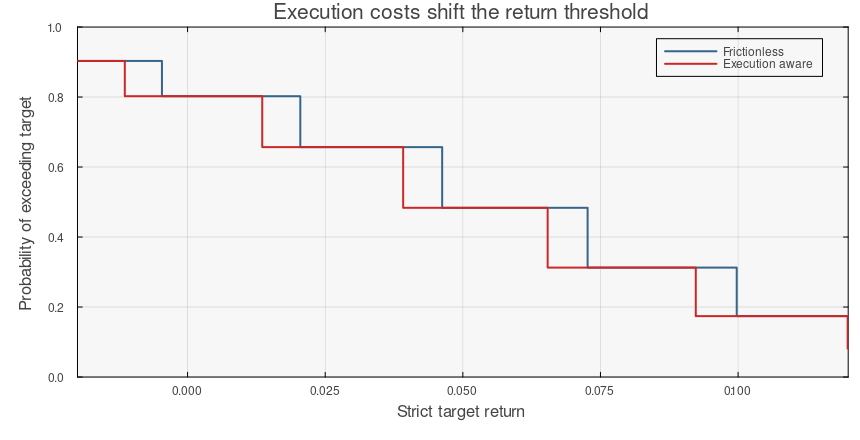

In [9]:
# Include every node return in the plotted range so each jump occurs at its threshold.
target_limits = (-0.02, 0.12)
node_returns = vcat(frictionless.outcomes.ρ, execution_aware.outcomes.ρ)
target_grid = sort(unique(vcat(
    collect(target_limits),
    filter(ρ -> target_limits[1] <= ρ <= target_limits[2], node_returns),
)))
frictionless_curve = [terminal_outcomes(; merge(common, (ρ_star=target,))...).probability_of_profit for target in target_grid]
execution_curve = [terminal_outcomes(; merge(common, (ρ_star=target,))..., execution...).probability_of_profit for target in target_grid]

# The strict target excludes a node at equality; each step extends to the right.
plot(
    target_grid, frictionless_curve;
    seriestype=:steppost, color=:steelblue4, label="Frictionless",
    xlabel="Strict target return", ylabel="Probability of exceeding target",
    title="Execution costs shift the return threshold",
    xlim=target_limits, ylim=(0, 1), yticks=0:0.2:1.0, size=(860, 440),
    left_margin=7mm, bottom_margin=7mm,
)
plot!(target_grid, execution_curve; seriestype=:steppost, color=:firebrick3, label="Execution aware")

As we raise the target, fewer terminal nodes qualify as successes, so the probability decreases in steps. When the target reaches a node’s return, that node no longer satisfies the strict inequality and its probability is removed from the total.

The execution-aware curve lies at or below the frictionless curve because costs reduce the return at every node. The gap between the curves shows how much these costs change the probability of exceeding each target.

### Vary the benchmark growth rate and holding period

__How do the benchmark growth rate and holding period affect our target probability?__ For a fixed holding period, a higher benchmark growth rate raises the terminal price needed to exceed the target. Changing the holding period also changes the number of lattice steps and the distribution of terminal prices, so we must recalculate the probability for each combination.

We compare holding periods of 5, 10, 20, and 40 trading days in `horizons`, and continuous annual benchmark growth rates of 0%, 4%, and 8% in `benchmark_rates`. We keep the target discounted return at 4%, with the same one-step lattice parameters and execution costs. For each combination, we calculate the minimum successful up-move count and target probability and collect the results in `stress_table`.

In [10]:
horizons = [5, 10, 20, 40]
benchmark_rates = [0.00, 0.04, 0.08]
stress_rows = NamedTuple[]
for horizon in horizons, benchmark_rate in benchmark_rates
    assumptions = merge(common, (N=horizon, g_y=benchmark_rate))
    result = terminal_outcomes(; assumptions..., execution...)
    push!(stress_rows, (
        steps=horizon, years=horizon*Δt, benchmark_growth_rate=benchmark_rate,
        k_min=result.k_min, probability_of_profit=result.probability_of_profit,
    ))
end
stress_table = DataFrame(stress_rows)

Row,steps,years,benchmark_growth_rate,k_min,probability_of_profit
,Int64,Float64,Float64,Int64,Float64
1,5,0.0198413,0.0,4,0.213499
2,5,0.0198413,0.04,4,0.213499
3,5,0.0198413,0.08,4,0.213499
4,10,0.0396825,0.0,6,0.427048
5,10,0.0396825,0.04,6,0.427048
6,10,0.0396825,0.08,7,0.206652
7,20,0.0793651,0.0,10,0.656841
8,20,0.0793651,0.04,11,0.483443
9,20,0.0793651,0.08,11,0.483443


For a 10-day holding period, raising the annual benchmark growth rate from 4% to 8% increases the minimum successful count from 6 to 7 up moves. The target probability falls from approximately 42.70% to 20.67%. A higher benchmark leaves the probability unchanged when the successful nodes remain the same.

A longer holding period can increase or decrease the target probability. At a 4% benchmark rate, extending the period from 5 to 40 days raises the probability from approximately 21.35% to 76.67%. At an 8% rate, extending it from 5 to 10 days lowers the probability from 21.35% to 20.67%. More time changes both the terminal price distribution and the required price threshold.

These values reflect the parameters above; your results may differ if you change them.

___

## Model Limitations

Within each scenario, we treat the spread, fees, and slippage as known constants. We keep the one-step lattice parameters $u$, $d$, and $p$ fixed when changing the holding period. Under these assumptions, terminal return increases with the up-move count, so we can calculate the target probability using a single cutoff.

Actual execution costs can vary with trade size, market conditions, and the price path. If costs depend on the node or path, successful outcomes may no longer be described by a single up-move cutoff. We would then need to account for those costs at the relevant nodes or along individual paths before calculating the target probability.

___


## Summary

In this example, we extended the L4a probability calculation to include execution costs and examined how trading assumptions affect the result.

> __Key Takeaways__
>
> * **Execution-aware cash flows:** We included the bid–ask spread, transaction fees, and slippage in the purchase and sale cash flows. Dividing the NPV by the complete initial outlay gave us a discounted fractional return that accounts for these costs.
> * **Terminal thresholds and target probabilities:** We derived the terminal mid-price and minimum up-move count needed to strictly exceed a target return. We checked the terminal-node returns and summed the probabilities of successful nodes to compare frictionless and execution-aware trades.
> * **Sensitivity to trading assumptions:** We varied execution costs, the target return, the benchmark growth rate, and the holding period. We saw why probabilities change in steps as nodes enter or leave the successful set, and why a longer holding period need not increase the target probability.

The resulting probability should therefore be interpreted alongside the price model, return target, and execution assumptions used to calculate it.

___


## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products, or any investment or trading advice or strategy, is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

Its execution assumptions are simplified and are not estimates of the cost of any specific trade. Actual fills can differ from quoted prices and may be partial or delayed.
